# Introdução

O câncer de mama é uma das doenças mais frequentes no mundo, e o diagnóstico precoce desempenha um papel fundamental no aumento das chances de tratamento e recuperação. Nesse contexto, técnicas de Inteligência Artificial têm se destacado como ferramentas de apoio à tomada de decisão médica, permitindo a construção de modelos capazes de identificar padrões em diferentes tipos de dados.

Neste Tech Challenge, foram comparadas duas abordagens para a predição do câncer de mama. A primeira utilizou o Wisconsin Breast Cancer Dataset, disponível no Kaggle, para treinar e avaliar modelos de Regressão Logística e Random Forest a partir de dados tabulares. A segunda empregou o CBIS-DDSM: Breast Cancer Image Dataset para desenvolver um modelo baseado em Redes Neurais Convolucionais (CNNs) e Visão Computacional, utilizando imagens de mamografias. Ao final, foi realizada uma análise comparativa entre as abordagens baseadas em dados tabulares e em imagens, destacando as diferenças de desempenho, vantagens, limitações e aplicações de cada método.

# Tópicos

1- Introdução <br>
2- Importação das bibliotecas e dos dados <br>
3- Conhecendo os dados <br>
4- Preparação dos dados <br>
3- Escolha do modelo (supervisionado) <br>

*   Regressão Logística
*   Random Forest

4- Treinar o modelo <br>
5- Testes <br>
6- Deploy <br>
7- Visão computacional

#Importação das bibliotecas e dos dados

*   Dataset de câncer de mama Wisconsin
*   Problema binário: Diagnóstico do exame, podendo ser **maligno** ou **benigno**
*   Abordagem: Aprendizado supervisionado

In [1]:
import pandas as pd
from google.colab import files, data_table
import io
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Realiza o download do arquivo salvo no drive
!gdown --id "1z3JF1r6ixWJsp_C6rDeWCHXP1kUIxQtD"

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1z3JF1r6ixWJsp_C6rDeWCHXP1kUIxQtD
To: /content/data.csv
100% 125k/125k [00:00<00:00, 32.7MB/s]


#Exibição dos dados

In [2]:
# Nome do arquivo
file_name = 'data.csv'

# Carrega o CSV para um DataFrame
df = pd.read_csv(f"./{file_name}")

In [3]:
print(f"Dimensões do dataset: {df.shape}")

Dimensões do dataset: (569, 33)


In [4]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
# Primeiras linhas do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
# Descrições estatísticas
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


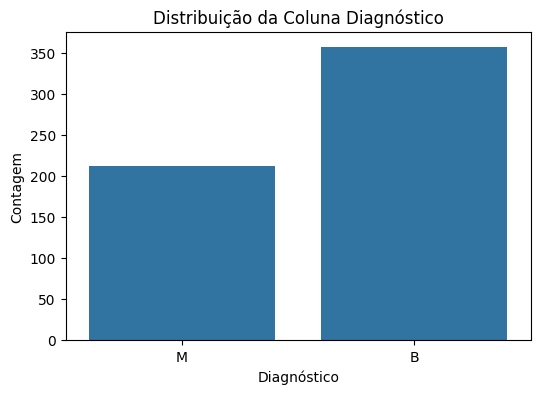

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df)
plt.title('Distribuição da Coluna Diagnóstico')
plt.xlabel('Diagnóstico')
plt.ylabel('Contagem')
plt.show()

# Análise Gráfica Malígno X Benigno

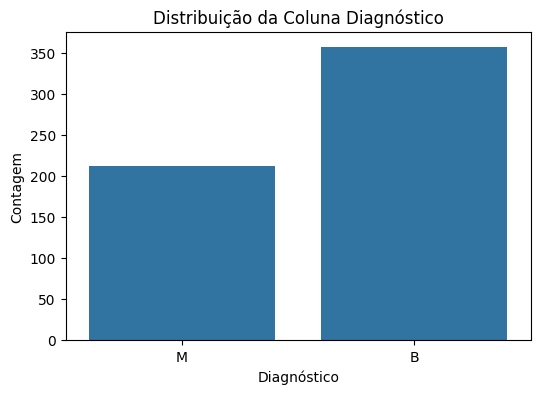

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df)
plt.title('Distribuição da Coluna Diagnóstico')
plt.xlabel('Diagnóstico')
plt.ylabel('Contagem')
plt.show()

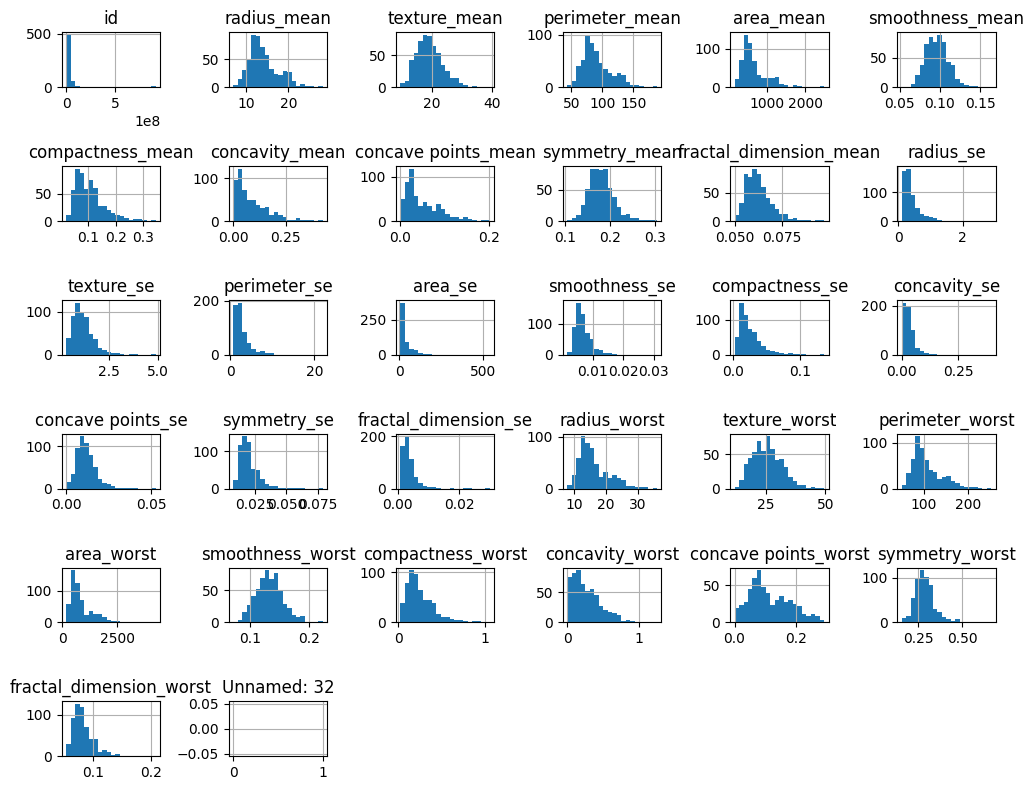

In [9]:
df.hist(bins=20, figsize=(10, 8))
plt.tight_layout()  # Arruma os títulos sobrepostos
plt.show()

# Preparação dos dados

*   Dataset escolhido: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data
*   Nome do arquivo: data.csv
*   Bibliotecas importadas: pandas

In [10]:
# Colunas dropadas
df.drop(['Unnamed: 32', 'id'], axis=1, inplace=True)

print(f"Arquivo '{file_name}' carregado com sucesso!")

# Exibe explicitamente o DataTable com 10 linhas por página e suporte a todas as colunas
display(data_table.DataTable(df, include_index=False, num_rows_per_page=15, max_columns=40))

Arquivo 'data.csv' carregado com sucesso!


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


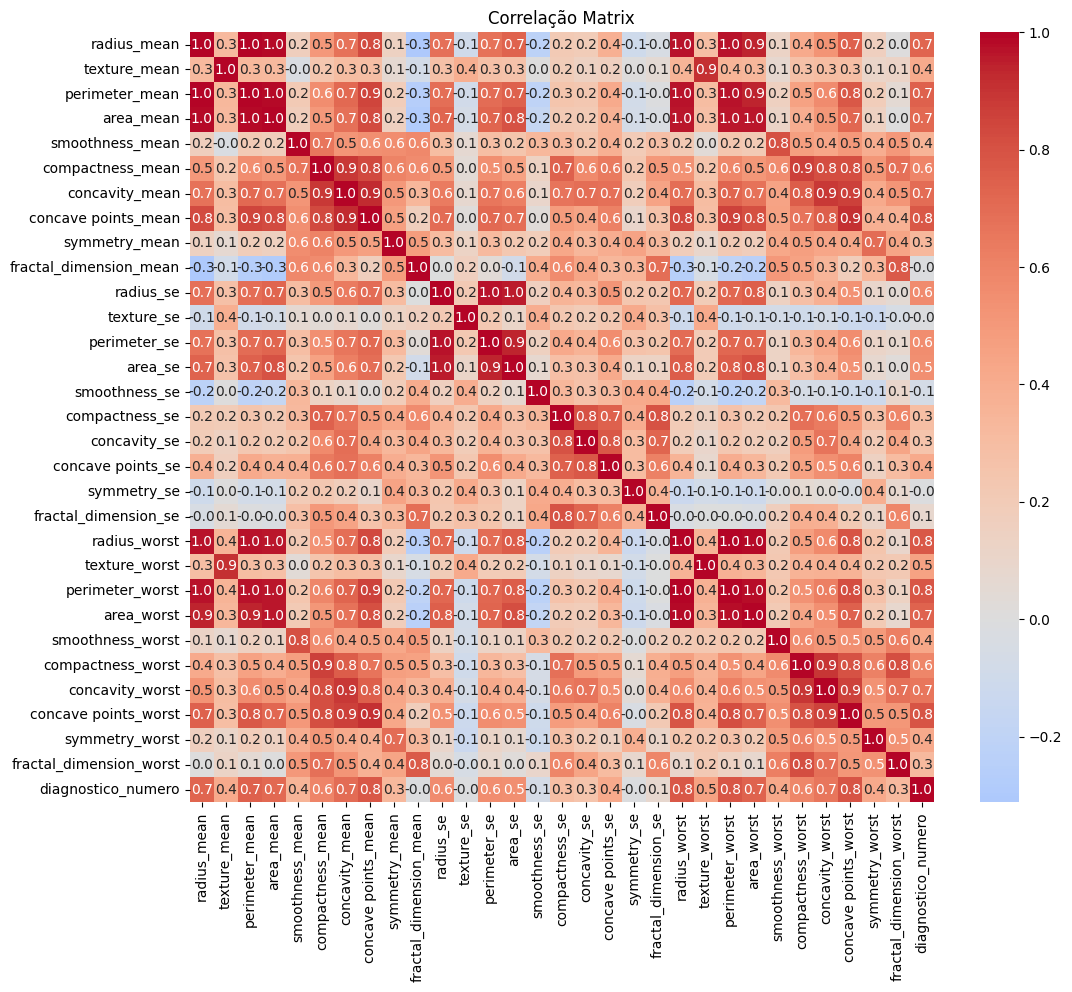

In [11]:
# Matriz de correlação

df["diagnostico_numero"] = df["diagnosis"].map({
    "B": 0,
    "M": 1
})

correlation = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".1f"
)

plt.title("Correlação Matrix")
plt.show()

In [12]:
all_numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
# Remove 'id' e 'diagnostico_numero' da lista de features para evitar correlação com si mesmas ou ID
features_to_correlate = [col for col in all_numeric_cols if col not in ['id', 'diagnostico_numero','diagnosis_numeric']]

# Adiciona 'diagnostico_numero' para calcular a correlação com as outras features
selected_features_for_corr = features_to_correlate + ['diagnostico_numero']

# Calcula a matriz de correlação para as características selecionadas
correlation_subset = df[selected_features_for_corr].corr()

# Exibe a correlação dessas características com 'diagnostico_numero'
display(correlation_subset['diagnostico_numero'].sort_values(ascending=False))

,diagnostico_numero
diagnostico_numero,1.000000
concave points_worst,0.793566
perimeter_worst,0.782914
concave points_mean,0.776614
radius_worst,0.776454
perimeter_mean,0.742636
area_worst,0.733825
radius_mean,0.730029
area_mean,0.708984
concavity_mean,0.696360


#Algoritmo de Regressão Logística

In [13]:
# Treino
X = df.drop(["diagnosis", "diagnostico_numero"], axis=1)

# Target
y = df["diagnostico_numero"]

In [14]:
pipeline_cv_full = Pipeline([
    ('scaler', StandardScaler()), # Padronização
    ('classifier', LogisticRegression(random_state=42, solver='liblinear')) # Classificação
])

# Configuração da validação cruzada
skf_full = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Validação com métrica de acurácia
scores_full_cv = cross_val_score(pipeline_cv_full, X, y, cv=skf_full, scoring='accuracy')

print("Acurácias para cada fold da validação cruzada")
for i, score in enumerate(scores_full_cv):
    print(f"Fold {i+1}: {score * 100:.2f}%")
print("---------------------------------------------------")
print(f"Acurácia média da validação cruzada: {scores_full_cv.mean() * 100:.2f}%") # Média entre os Folds
print(f"Desvio padrão das acurácias: {scores_full_cv.std() * 100:.2f}%") # Devio padrão

Acurácias para cada fold da validação cruzada
Fold 1: 97.37%
Fold 2: 95.61%
Fold 3: 96.49%
Fold 4: 99.12%
Fold 5: 99.12%
---------------------------------------------------
Acurácia média da validação cruzada: 97.54%
Desvio padrão das acurácias: 1.40%


# Random Forest

In [15]:
# 1. Separação das Variáveis
x = df.drop(["diagnosis", "diagnostico_numero"], axis=1)
y = df['diagnosis']

In [16]:
# 2. Divisão dos Dados (70% Treino, 30% Teste)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y, random_state=42)

# 3. Definição do Modelo e Grade de Hiperparâmetros
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [10, 30, 50, 70, 90], # Quantidade de árvores normais para o modelo
    'max_depth': [2, 4, 6, 8, 10]        # Testando diferentes profundidades
}

In [17]:
# 4. Busca pelos Melhores Hiperparâmetros
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(x_train, y_train)

# 5. Resultados
print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")

Melhores parâmetros encontrados: {'max_depth': 6, 'n_estimators': 50}


In [18]:
melhor_modelo = grid_search.best_estimator_

y_predict_rf = melhor_modelo.predict(x_test)
print(f"Acurácia final no Teste: {accuracy_score(y_test, y_predict_rf):.4f}")

Acurácia final no Teste: 0.9649


### **Tarefa extra - Visão Computacional**

Instalação da biblioteca do Kaggle utilizando a credencial de API, e baixamos o dataset CBIS-DDSM.

In [19]:
!pip install -q kaggle

In [20]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"camilautz","key":"b746424e683ce5bd400b2b271d024272"}'}

Carregado arquivo de descrição dos casos de massas mamárias, que traz, para cada exame, informações como densidade da mama, lateralidade, e o diagnóstico.

In [21]:
!kaggle datasets download -d awsaf49/cbis-ddsm-breast-cancer-image-dataset
!unzip -q cbis-ddsm-breast-cancer-image-dataset.zip -d cbis_ddsm

Dataset URL: https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
License(s): CC-BY-SA-3.0
cbis-ddsm-breast-cancer-image-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace cbis_ddsm/csv/calc_case_description_test_set.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace cbis_ddsm/csv/calc_case_description_train_set.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace cbis_ddsm/csv/dicom_info.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace cbis_ddsm/csv/mass_case_description_test_set.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace cbis_ddsm/csv/mass_case_description_train_set.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace cbis_ddsm/csv/meta.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace cbis_ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.100018879311824535125115145152454291132/1-263.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace cbis_ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.1000188793118245351251151451

Dados

In [22]:
import pandas as pd
import os

df = pd.read_csv(
    "/content/cbis_ddsm/csv/mass_case_description_train_set.csv"
)

print(df.head())
print(df.columns)

  patient_id  breast_density left or right breast image view  abnormality id  \
0    P_00001               3                 LEFT         CC               1   
1    P_00001               3                 LEFT        MLO               1   
2    P_00004               3                 LEFT         CC               1   
3    P_00004               3                 LEFT        MLO               1   
4    P_00004               3                RIGHT        MLO               1   

  abnormality type                          mass shape   mass margins  \
0             mass  IRREGULAR-ARCHITECTURAL_DISTORTION     SPICULATED   
1             mass  IRREGULAR-ARCHITECTURAL_DISTORTION     SPICULATED   
2             mass            ARCHITECTURAL_DISTORTION    ILL_DEFINED   
3             mass            ARCHITECTURAL_DISTORTION    ILL_DEFINED   
4             mass                                OVAL  CIRCUMSCRIBED   

   assessment  pathology  subtlety  \
0           4  MALIGNANT         4   
1   

Convertida a coluna de diagnóstico em um rótulo binário: 0 para benigno, 1 para maligno.

In [23]:
df["label"] = df["pathology"].map({
    "BENIGN": 0,
    "BENIGN_WITHOUT_CALLBACK": 0,
    "MALIGNANT": 1
})

Dividimos os dados em 70% treino, 15% validação e 15% teste, usando estratificação para manter a mesma proporção de casos malignos e benignos em cada grupo. Isso resultou em 922 imagens de treino, 198 de validação e 198 de teste.

In [24]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

In [25]:
BASE_DIR = "/content/cbis_ddsm"

train_paths = [
    os.path.join(BASE_DIR, p)
    for p in train_df["image file path"]
]

val_paths = [
    os.path.join(BASE_DIR, p)
    for p in val_df["image file path"]
]

test_paths = [
    os.path.join(BASE_DIR, p)
    for p in test_df["image file path"]
]

Definido o tamanho padrão das imagens (224x224 pixels) e o tamanho do lote de treino. A função process_image lê cada arquivo, decodifica como JPEG, redimensiona e normaliza os valores de pixel para o intervalo 0-1

In [26]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

In [27]:
def process_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = image / 255.0

    return image, label

In [28]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_paths,
        train_df["label"].values
    )
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_paths,
        val_df["label"].values
    )
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_paths,
        test_df["label"].values
    )
)

In [29]:
train_ds = (
    train_ds
    .map(process_image)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .map(process_image)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .map(process_image)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [30]:
train_ds
val_ds
test_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [31]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Bloco 1: detecta padrões simples (bordas, texturas)
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Bloco 2: combina padrões simples em padrões mais complexos
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Bloco 3: padrões ainda mais abstratos
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Achata tudo em um vetor e decide a classificação
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
import re

# Carrega o "mapa" de tradução dicom -> jpeg
dicom_df = pd.read_csv("/content/cbis_ddsm/csv/dicom_info.csv")

# Monta um dicionário: UID -> caminho real do jpg
# Pega só as linhas que são "full mammogram images" (a imagem completa, não o crop nem a máscara)
full_images = dicom_df[dicom_df["SeriesDescription"] == "full mammogram images"]

uid_to_jpg = dict(zip(full_images["SeriesInstanceUID"], full_images["image_path"]))

def extract_uid(path):
    # Pega o primeiro UID (sequência longa de números separados por ponto) no caminho
    match = re.search(r"\d+\.\d+\.\d+\.\d+\.\d+\.\d+\.\d+\.\d+\.\d+\.\d+\.\d+(?:\.\d+)*", path)
    return match.group(0) if match else None

def resolve_jpg_path(original_path):
    uid = extract_uid(original_path)
    if uid in uid_to_jpg:
        # image_path vem como "CBIS-DDSM/jpeg/<uid>/<arquivo>.jpg"
        # precisamos trocar o prefixo "CBIS-DDSM/" pelo BASE_DIR real
        relative = uid_to_jpg[uid].replace("CBIS-DDSM/", "")
        return os.path.join(BASE_DIR, relative)
    return None

BASE_DIR = "/content/cbis_ddsm"

train_df["resolved_path"] = train_df["image file path"].apply(resolve_jpg_path)
val_df["resolved_path"] = val_df["image file path"].apply(resolve_jpg_path)
test_df["resolved_path"] = test_df["image file path"].apply(resolve_jpg_path)

# Confere quantos caminhos foram resolvidos com sucesso
print("Treino - resolvidos:", train_df["resolved_path"].notna().sum(), "de", len(train_df))
print("Validação - resolvidos:", val_df["resolved_path"].notna().sum(), "de", len(val_df))
print("Teste - resolvidos:", test_df["resolved_path"].notna().sum(), "de", len(test_df))

Treino - resolvidos: 0 de 922
Validação - resolvidos: 0 de 198
Teste - resolvidos: 0 de 198


In [33]:
def extract_uid(path):
    # Pega TODOS os UIDs no caminho (pode ter mais de um empilhado)
    matches = re.findall(r"\d+\.\d+\.\d+\.\d+\.\d+\.\d+\.\d+\.\d+\.\d+\.\d+\.\d+(?:\.\d+)*", path)
    return matches[-1] if matches else None  # pega o último (o mais interno, que é o da série)

def resolve_jpg_path(original_path):
    uid = extract_uid(original_path)
    if uid in uid_to_jpg:
        relative = uid_to_jpg[uid].replace("CBIS-DDSM/", "")
        return os.path.join(BASE_DIR, relative)
    return None

train_df["resolved_path"] = train_df["image file path"].apply(resolve_jpg_path)
val_df["resolved_path"] = val_df["image file path"].apply(resolve_jpg_path)
test_df["resolved_path"] = test_df["image file path"].apply(resolve_jpg_path)

print("Treino - resolvidos:", train_df["resolved_path"].notna().sum(), "de", len(train_df))
print("Validação - resolvidos:", val_df["resolved_path"].notna().sum(), "de", len(val_df))
print("Teste - resolvidos:", test_df["resolved_path"].notna().sum(), "de", len(test_df))

Treino - resolvidos: 922 de 922
Validação - resolvidos: 198 de 198
Teste - resolvidos: 198 de 198


In [34]:
train_paths = train_df["resolved_path"].tolist()
val_paths = val_df["resolved_path"].tolist()
test_paths = test_df["resolved_path"].tolist()

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_df["label"].values)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_df["label"].values)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_df["label"].values)
)

train_ds = (
    train_ds
    .map(process_image)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .map(process_image)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .map(process_image)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

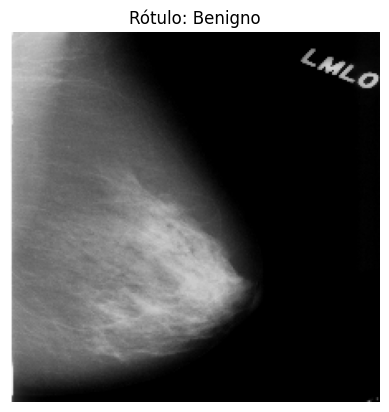

In [35]:
import matplotlib.pyplot as plt

for image, label in train_ds.take(1):
    plt.imshow(image[0])
    plt.title(f"Rótulo: {'Maligno' if label[0]==1 else 'Benigno'}")
    plt.axis("off")
    plt.show()
    break

Treinamos o modelo por 10 épocas. A acurácia de treino evoluiu progressivamente, mas a de validação ficou abaixo, sinalizando overfitting.

In [36]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 182s 4s/step - accuracy: 0.4935 - loss: 0.7542 - val_accuracy: 0.5404 - val_loss: 0.6919
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 199s 4s/step - accuracy: 0.5228 - loss: 0.6952 - val_accuracy: 0.5152 - val_loss: 0.6926
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 202s 4s/step - accuracy: 0.5813 - loss: 0.6778 - val_accuracy: 0.5859 - val_loss: 0.6637
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 175s 4s/step - accuracy: 0.6323 - loss: 0.6354 - val_accuracy: 0.6566 - val_loss: 0.6472
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 201s 4s/step - accuracy: 0.7310 - loss: 0.5562 - val_accuracy: 0.6667 - val_loss: 0.6227
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 224s 4s/step - accuracy: 0.7603 - loss: 0.4765 - val_accuracy: 0.6717 - val_loss: 0.6570
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 176s 4s/step - accuracy: 0.8438 - loss: 0.3572 - val_accuracy: 0.7121 - val_loss: 0.6802
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 222s 5s/step - accuracy: 0.8937 - loss: 0.2561 - val_accuracy: 0.6869 - v

Os gráficos de acurácia e perda por época confirmam esse padrão: o desempenho no treino melhora consistentemente, enquanto a validação estabiliza e a perda de validação chega a aumentar nas últimas épocas.

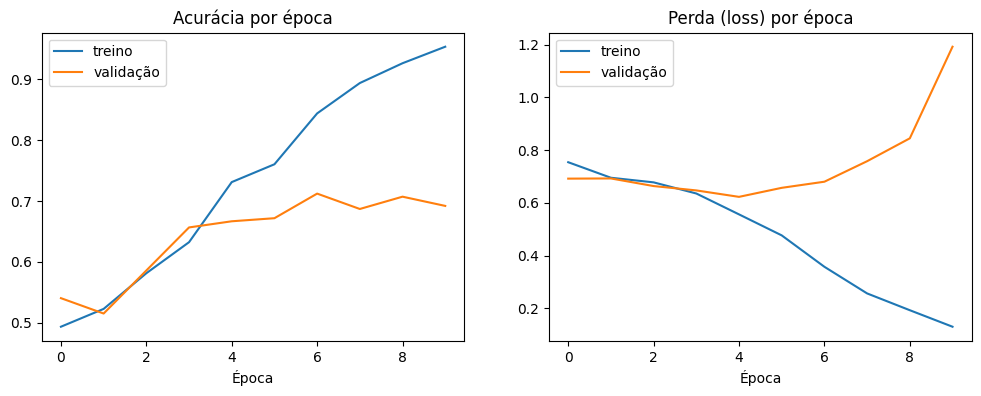

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="treino")
plt.plot(history.history["val_accuracy"], label="validação")
plt.title("Acurácia por época")
plt.xlabel("Época")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="treino")
plt.plot(history.history["val_loss"], label="validação")
plt.title("Perda (loss) por época")
plt.xlabel("Época")
plt.legend()

plt.show()

No conjunto de testeobtivemos acurácia de 0.62, com recall de 0.56 para a classe maligna.

7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step
              precision    recall  f1-score   support

     Benigno       0.60      0.62      0.61       103
     Maligno       0.58      0.56      0.57        95

    accuracy                           0.59       198
   macro avg       0.59      0.59      0.59       198
weighted avg       0.59      0.59      0.59       198



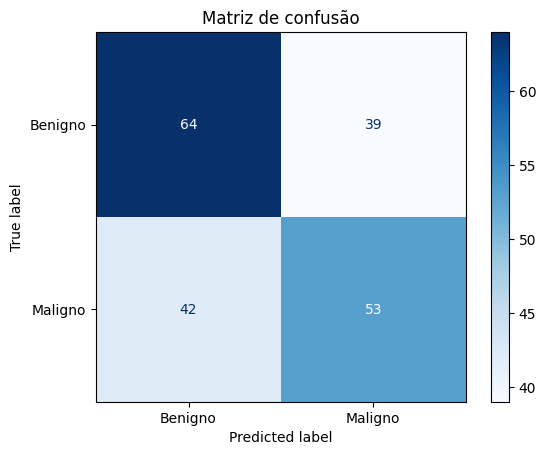

In [38]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_probs = model.predict(test_ds)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

y_true = test_df["label"].values

print(classification_report(y_true, y_pred, target_names=["Benigno", "Maligno"]))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Benigno", "Maligno"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusão")
plt.show()

Para interpretar como o modelo toma suas decisões, aplicamos Grad-CAM, que evidencia as regiões da imagem mais relevantes para a classificação. Identificamos que parte da atenção do modelo recai sobre elementos que não são tecido mamário, como marcações técnicas da imagem.

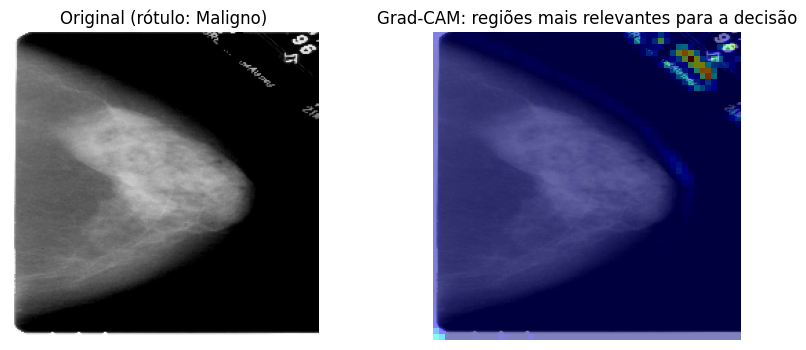

In [39]:
import matplotlib.cm as cm
import numpy as np

def make_gradcam_heatmap(img_array, model, last_conv_layer_index=4):
    with tf.GradientTape() as tape:
        x = img_array
        conv_output = None
        for i, layer in enumerate(model.layers):
            x = layer(x)
            if i == last_conv_layer_index:
                tape.watch(x)
                conv_output = x
        predictions = x
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Pega uma imagem de exemplo do conjunto de teste
for images, labels in test_ds.take(1):
    sample_image = images[0:1]
    sample_label = labels[0].numpy()
    break

heatmap = make_gradcam_heatmap(sample_image, model)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample_image[0])
plt.title(f"Original (rótulo: {'Maligno' if sample_label==1 else 'Benigno'})")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample_image[0])
plt.imshow(heatmap, cmap="jet", alpha=0.5, extent=(0, IMG_SIZE, IMG_SIZE, 0))
plt.title("Grad-CAM: regiões mais relevantes para a decisão")
plt.axis("off")

plt.show()